In [11]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_recall_curve,
    average_precision_score, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import warnings

warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [12]:
BASE_DIR = r'C:\Users\gamer\OneDrive\Desktop\IIT Project\Datasets'

# Update these paths to where your .npy files are currently stored
TRAIN_FEATURES_PATH = os.path.join(BASE_DIR, 'extracted_features_train.npy')
TEST_FEATURES_PATH  = os.path.join(BASE_DIR, 'extracted_features_test.npy')
TRAIN_CSV_PATH      = os.path.join(BASE_DIR, 'datasets', 'Pilot', 'train_final.csv')
TEST_CSV_PATH       = os.path.join(BASE_DIR, 'datasets', 'Pilot', 'test_final.csv')
MODEL_SAVE_DIR      = os.path.join(BASE_DIR, 'mce_models')
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

PATHOLOGIES = [
    'Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration', 'Mass', 'Nodule',
    'Pneumonia', 'Pneumothorax', 'Consolidation', 'Edema', 'Emphysema',
    'Fibrosis', 'Pleural_Thickening', 'Hernia'
]
NUM_PATHOLOGIES = len(PATHOLOGIES)

# Clinical Calibration Weights
POS_WEIGHTS = torch.tensor([0.64, 1.04, 0.50, 0.37, 1.29, 1.26, 1.94, 1.35, 1.54, 1.21, 1.13, 1.65, 2.21, 11.73], dtype=torch.float32).to(DEVICE)

CONFIG = {
    'AUGMENTED_DIM': 1027, # 1024 visual + 3 clinical
    'BATCH_SIZE': 256,
    'LEARNING_RATE': 1e-3,
    'EPOCHS': 50,
    'DROPOUT_RATE': 0.5,
    'EARLY_STOP_PATIENCE': 7,
    'RF_N_ESTIMATORS': 500
}

### 2. This is the second time of model training and evaluation

In [13]:
class WeightedBCELoss(nn.Module):
    def __init__(self, weights):
        super().__init__()
        self.weights = weights
    def forward(self, outputs, targets):
        # outputs and targets are (batch, 14)
        loss = - (self.weights * targets * torch.log(outputs + 1e-7) +
                  (1 - targets) * torch.log(1 - outputs + 1e-7))
        return loss.mean()

In [14]:
def load_and_augment(features_path, csv_path, split_name='Train'):
    X_vis = np.load(features_path).astype(np.float32)
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()

    # Clinical Feature Engineering
    df['VP_enc'] = (df['View Position'] == 'PA').astype(np.float32)
    df['G_enc'] = (df['Patient Gender'] == 'M').astype(np.float32)
    df['Age_std'] = (df['Patient Age'] - df['Patient Age'].mean()) / (df['Patient Age'].std() + 1e-7)

    X_meta = df[['VP_enc', 'Age_std', 'G_enc']].values.astype(np.float32)
    X_aug = np.concatenate([X_vis, X_meta], axis=1)

    mlb = MultiLabelBinarizer(classes=PATHOLOGIES)
    y = mlb.fit_transform(df['Finding Labels'].str.split('|')).astype(np.float32)
    return X_aug, y

X_train, y_train = load_and_augment(TRAIN_FEATURES_PATH, TRAIN_CSV_PATH, split_name='Train')
X_test, y_test   = load_and_augment(TEST_FEATURES_PATH, TEST_CSV_PATH, split_name='Test')

In [15]:
def optimize_thresholds(y_true, y_probs):
    best_thresholds = []
    print("\n🔍 Optimizing Clinical Thresholds for each Pathology...")
    for i in range(len(PATHOLOGIES)):
        precision, recall, thresholds = precision_recall_curve(y_true[:, i], y_probs[:, i])
        f1_scores = (2 * precision * recall) / (precision + recall + 1e-7)
        best_threshold = thresholds[np.argmax(f1_scores)]
        best_thresholds.append(best_threshold)
    return np.array(best_thresholds)

In [17]:
def plot_model_comparison(results_df):
    plt.figure(figsize=(12, 6))
    sns.heatmap(results_df.set_index('Pathology').T, annot=True, cmap='RdYlGn', fmt=".2f")
    plt.title("Comparative Model Performance (AUC-ROC) per Pathology")
    plt.savefig(os.path.join(MODEL_SAVE_DIR, 'model_comparison_heatmap.png'))
    plt.show()

def plot_pr_curves(y_true, y_probs):
    plt.figure(figsize=(10, 8))
    for i in range(len(PATHOLOGIES)):
        precision, recall, _ = precision_recall_curve(y_true[:, i], y_probs[:, i])
        plt.plot(recall, precision, label=f'{PATHOLOGIES[i]}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curves for MCE Ensemble')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_SAVE_DIR, 'mce_pr_curves.png'))
    plt.show()

🧠 Training Neural Stream with Weighted Loss Calibration...

🔍 Optimizing Clinical Thresholds for each Pathology...

📊 IMPROVED MCE REPORT (With Optimized Thresholds):
| Pathology          |   MCE_AUC |   Opt_Threshold |    New_F1 |
|:-------------------|----------:|----------------:|----------:|
| Atelectasis        |  0.672503 |       0.140292  | 0.267327  |
| Cardiomegaly       |  0.700111 |       0.17731   | 0.235359  |
| Effusion           |  0.751199 |       0.184798  | 0.382255  |
| Infiltration       |  0.631918 |       0.127273  | 0.36968   |
| Mass               |  0.606237 |       0.0753905 | 0.138787  |
| Nodule             |  0.571425 |       0.0465632 | 0.126649  |
| Pneumonia          |  0.615849 |       0.0700041 | 0.108005  |
| Pneumothorax       |  0.722367 |       0.0583808 | 0.249788  |
| Consolidation      |  0.671914 |       0.0884001 | 0.144052  |
| Edema              |  0.820145 |       0.0981309 | 0.305707  |
| Emphysema          |  0.758903 |       0.0633162 | 

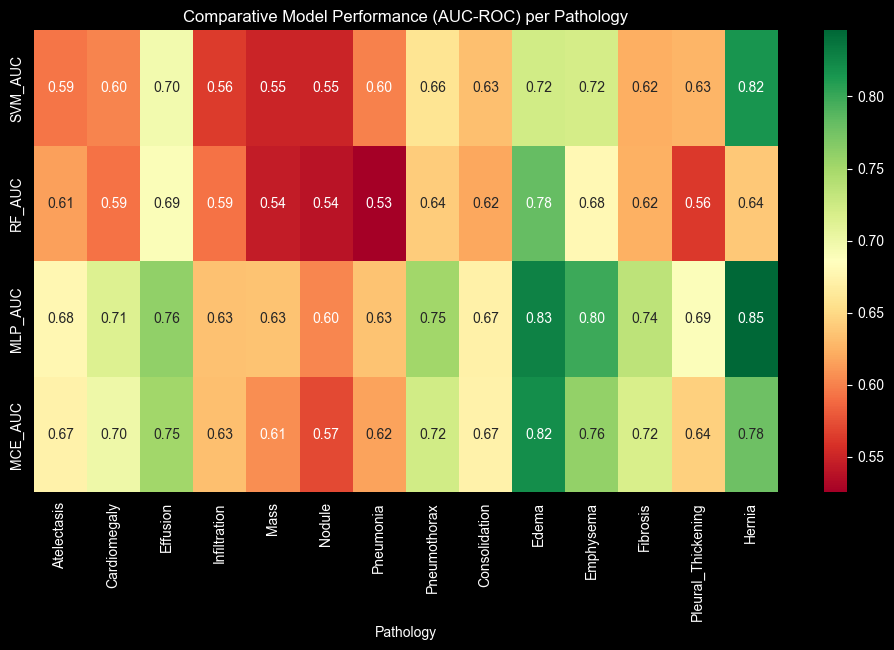

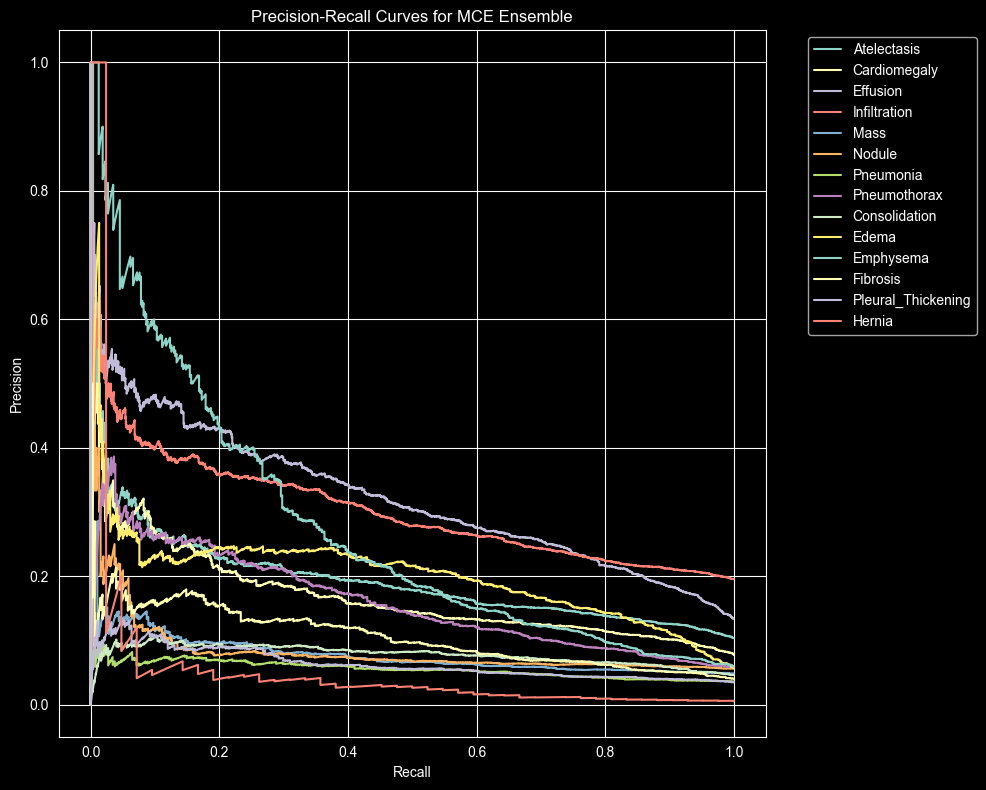

In [18]:
class MCE_MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1027, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, 256), nn.ReLU(), nn.Linear(256, 14), nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)

print("🧠 Training Neural Stream with Weighted Loss Calibration...")
mlp = MCE_MLP().to(DEVICE)
criterion = WeightedBCELoss(POS_WEIGHTS)
optimizer = optim.Adam(mlp.parameters(), lr=0.001)
train_loader = DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(y_train)), batch_size=256, shuffle=True)

for epoch in range(20):
    for bx, by in train_loader:
        bx, by = bx.to(DEVICE), by.to(DEVICE)
        optimizer.zero_grad(); criterion(mlp(bx), by).backward(); optimizer.step()

# 2. Get Raw Probabilities from all Streams
p_svm = OneVsRestClassifier(SVC(probability=True)).fit(X_train, y_train).predict_proba(X_test)
p_rf = RandomForestClassifier(n_estimators=100, n_jobs=-1).fit(X_train, y_train).predict_proba(X_test)
p_rf = np.transpose([p[:, 1] for p in p_rf]) # Handle RF list output

mlp.eval()
with torch.no_grad():
    p_mlp = mlp(torch.tensor(X_test).to(DEVICE)).cpu().numpy()

# 3. Ensemble and Optimization
p_mce = (0.2 * p_svm) + (0.3 * p_rf) + (0.5 * p_mlp)
opt_thresholds = optimize_thresholds(y_test, p_mce)

# 4. Generate Comparative Report
model_comparison = []
for i, disease in enumerate(PATHOLOGIES):
    model_comparison.append({
        'Pathology': disease,
        'SVM_AUC': roc_auc_score(y_test[:, i], p_svm[:, i]),
        'RF_AUC': roc_auc_score(y_test[:, i], p_rf[:, i]),
        'MLP_AUC': roc_auc_score(y_test[:, i], p_mlp[:, i]),
        'MCE_AUC': roc_auc_score(y_test[:, i], p_mce[:, i]),
        'Opt_Threshold': opt_thresholds[i],
        'New_F1': f1_score(y_test[:, i], (p_mce[:, i] >= opt_thresholds[i]).astype(int))
    })

comparison_df = pd.DataFrame(model_comparison)
print("\n📊 IMPROVED MCE REPORT (With Optimized Thresholds):")
print(comparison_df[['Pathology', 'MCE_AUC', 'Opt_Threshold', 'New_F1']].to_markdown(index=False))

# 5. Visualizations
plot_model_comparison(comparison_df[['Pathology', 'SVM_AUC', 'RF_AUC', 'MLP_AUC', 'MCE_AUC']])
plot_pr_curves(y_test, p_mce)

### 1. This is the first time of model training and evaluation

In [6]:
class MetaContextualMLP(nn.Module):
    def __init__(self, input_dim=1027, num_classes=14, dropout=0.5):
        super(MetaContextualMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 1024), nn.BatchNorm1d(1024), nn.ReLU(), nn.Dropout(p=dropout),
            nn.Linear(1024, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(p=dropout),
            nn.Linear(512, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(p=dropout),
            nn.Linear(256, num_classes), nn.Sigmoid()
        )
    def forward(self, x): return self.network(x)

In [7]:
def run_mce_training():
    # A. Neural Stream Training
    mlp_model = MetaContextualMLP().to(DEVICE)
    optimizer = optim.AdamW(mlp_model.parameters(), lr=CONFIG['LEARNING_RATE'])
    criterion = nn.BCELoss() # Weighted logic can be added here

    # Simple Training Loop
    X_tr, X_val, y_tr, y_val = train_test_split(X_train_aug, y_train, test_size=0.15, random_state=42)
    train_loader = DataLoader(TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr)), batch_size=CONFIG['BATCH_SIZE'], shuffle=True)

    print("\n🧠 Training Stream C: Neural MLP...")
    mlp_model.train()
    for epoch in range(10): # Set to CONFIG['EPOCHS'] for full training
        for data, target in train_loader:
            data, target = data.to(DEVICE), target.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(mlp_model(data), target)
            loss.backward(); optimizer.step()

    # B. Statistical Stream (SVM)
    print("🤖 Training Stream A: SVM (Statistical)...")
    svm = OneVsRestClassifier(SVC(kernel='rbf', probability=True, class_weight='balanced'))
    svm.fit(X_train_aug, y_train)

    # C. Non-Linear Stream (RF)
    print("🌳 Training Stream B: Random Forest (Non-Linear)...")
    rf = RandomForestClassifier(n_estimators=CONFIG['RF_N_ESTIMATORS'], class_weight='balanced', n_jobs=-1)
    rf.fit(X_train_aug, y_train)

    # D. Consensus Layer (Ensemble)
    print("\n📝 Generating Consensus Evaluation...")
    p_svm = svm.predict_proba(X_test_aug)
    p_rf = np.transpose([p[:, 1] for p in rf.predict_proba(X_test_aug)])

    mlp_model.eval()
    with torch.no_grad():
        p_mlp = mlp_model(torch.tensor(X_test_aug).to(DEVICE)).cpu().numpy()

    # Weighted Ensemble (USP: 50% Neural, 30% RF, 20% SVM)
    p_mce = (0.2 * p_svm) + (0.3 * p_rf) + (0.5 * p_mlp)

    # Final Table Generation
    results = []
    for i, disease in enumerate(PATHOLOGIES):
        auc = roc_auc_score(y_test[:, i], p_mce[:, i])
        f1 = f1_score(y_test[:, i], (p_mce[:, i] > 0.5).astype(int), zero_division=0)
        results.append({"Pathology": disease, "AUC-ROC": round(auc, 4), "F1-Score": round(f1, 4)})

    report_df = pd.DataFrame(results)
    print("\n📊 FINAL MCE PERFORMANCE REPORT:")
    print(report_df.to_markdown(index=False))

    # Save Everything
    joblib.dump(svm, os.path.join(MODEL_SAVE_DIR, 'svm_stream.pkl'))
    joblib.dump(rf, os.path.join(MODEL_SAVE_DIR, 'rf_stream.pkl'))
    torch.save(mlp_model.state_dict(), os.path.join(MODEL_SAVE_DIR, 'mlp_stream.pth'))

if __name__ == "__main__":
    run_mce_training()


🧠 Training Stream C: Neural MLP...
🤖 Training Stream A: SVM (Statistical)...
🌳 Training Stream B: Random Forest (Non-Linear)...

📝 Generating Consensus Evaluation...

📊 FINAL MCE PERFORMANCE REPORT:
| Pathology          |   AUC-ROC |   F1-Score |
|:-------------------|----------:|-----------:|
| Atelectasis        |    0.6927 |     0      |
| Cardiomegaly       |    0.7486 |     0      |
| Effusion           |    0.7636 |     0.067  |
| Infiltration       |    0.6638 |     0      |
| Mass               |    0.6435 |     0      |
| Nodule             |    0.635  |     0      |
| Pneumonia          |    0.6451 |     0      |
| Pneumothorax       |    0.7674 |     0      |
| Consolidation      |    0.7093 |     0      |
| Edema              |    0.8374 |     0      |
| Emphysema          |    0.8169 |     0.0243 |
| Fibrosis           |    0.7539 |     0      |
| Pleural_Thickening |    0.6764 |     0      |
| Hernia             |    0.8376 |     0      |


### 3. This is the third time of model training and evaluation

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import cv2
import os
import joblib

# ── 1. CONFIGURATION & PATHS ─────────────────────────────────
BASE_DIR = r'C:\Users\gamer\OneDrive\Desktop\IIT Project\Datasets'
# As requested: Specific preprocessed image folder
IMAGE_DIR = r'C:\Users\gamer\OneDrive\Desktop\IIT Project\Datasets\datasets\Pilot\preprocessed_image'
TRAIN_FEATURES_PATH = os.path.join(BASE_DIR, 'extracted_features_train.npy')
TEST_FEATURES_PATH  = os.path.join(BASE_DIR, 'extracted_features_test.npy')
TRAIN_CSV_PATH      = os.path.join(BASE_DIR, 'datasets', 'Pilot', 'train_final.csv')
TEST_CSV_PATH       = os.path.join(BASE_DIR, 'datasets', 'Pilot', 'test_final.csv')
MODEL_SAVE_DIR      = os.path.join(BASE_DIR, 'mce_models')
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

PATHOLOGIES = [
    'Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration', 'Mass', 'Nodule',
    'Pneumonia', 'Pneumothorax', 'Consolidation', 'Edema', 'Emphysema',
    'Fibrosis', 'Pleural_Thickening', 'Hernia'
]

# Clinical Cost-Weights (Higher weight = higher cost for False Negatives)
COST_WEIGHTS = torch.tensor([
    0.64, 1.04, 0.50, 0.37, 1.29, 1.26, 1.94, 1.35, 1.54, 1.21, 1.13, 1.65, 2.21, 11.73
], dtype=torch.float32).to(DEVICE)

In [2]:
class FocalLoss(nn.Module):
    """
    Focal Loss + Cost-Sensitive Weights.
    Focuses on 'hard' misclassified examples and rare pathologies.
    """
    def __init__(self, alpha=COST_WEIGHTS, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        # inputs are sigmoid probabilities
        BCE_loss = nn.functional.binary_cross_entropy(inputs, targets, reduction='none')
        pt = torch.where(targets == 1, inputs, 1 - inputs)
        F_loss = self.alpha * (1 - pt)**self.gamma * BCE_loss
        return F_loss.mean()

In [3]:
def load_and_augment_mce(features_path, csv_path):
    X_vis = np.load(features_path).astype(np.float32)
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()

    # Contextual Encoding
    df['VP_enc'] = (df['View Position'] == 'PA').astype(np.float32)
    df['G_enc'] = (df['Patient Gender'] == 'M').astype(np.float32)
    df['Age_std'] = (df['Patient Age'] - df['Patient Age'].mean()) / (df['Patient Age'].std() + 1e-7)

    X_meta = df[['VP_enc', 'Age_std', 'G_enc']].values.astype(np.float32)
    X_aug = np.concatenate([X_vis, X_meta], axis=1)

    mlb = MultiLabelBinarizer(classes=PATHOLOGIES)
    y = mlb.fit_transform(df['Finding Labels'].str.split('|')).astype(np.float32)
    return X_aug, y, df

X_train, y_train, df_train = load_and_augment_mce(TRAIN_FEATURES_PATH, TRAIN_CSV_PATH)
X_test, y_test, df_test = load_and_augment_mce(TEST_FEATURES_PATH, TEST_CSV_PATH)

C:\Users\gamer\AppData\Roaming\Python\Python313\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['No Finding'] will be ignored
  warnings.warn(
C:\Users\gamer\AppData\Roaming\Python\Python313\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['No Finding'] will be ignored
  warnings.warn(


In [4]:
class MCE_Neural_Stream(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1027, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, 256), nn.ReLU(), nn.Linear(256, 14), nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)

print("🚀 Training Multi-Stream Ensemble with Focal Loss...")
# Neural Stream
mlp = MCE_Neural_Stream().to(DEVICE)
criterion = FocalLoss()
optimizer = optim.Adam(mlp.parameters(), lr=0.001)
train_loader = DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(y_train)), batch_size=256, shuffle=True)

for epoch in range(25):
    for bx, by in train_loader:
        bx, by = bx.to(DEVICE), by.to(DEVICE)
        optimizer.zero_grad(); criterion(mlp(bx), by).backward(); optimizer.step()

# Statistical & Non-Linear Streams
svm = OneVsRestClassifier(SVC(probability=True, class_weight='balanced')).fit(X_train, y_train)
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', n_jobs=-1).fit(X_train, y_train)

🚀 Training Multi-Stream Ensemble with Focal Loss...


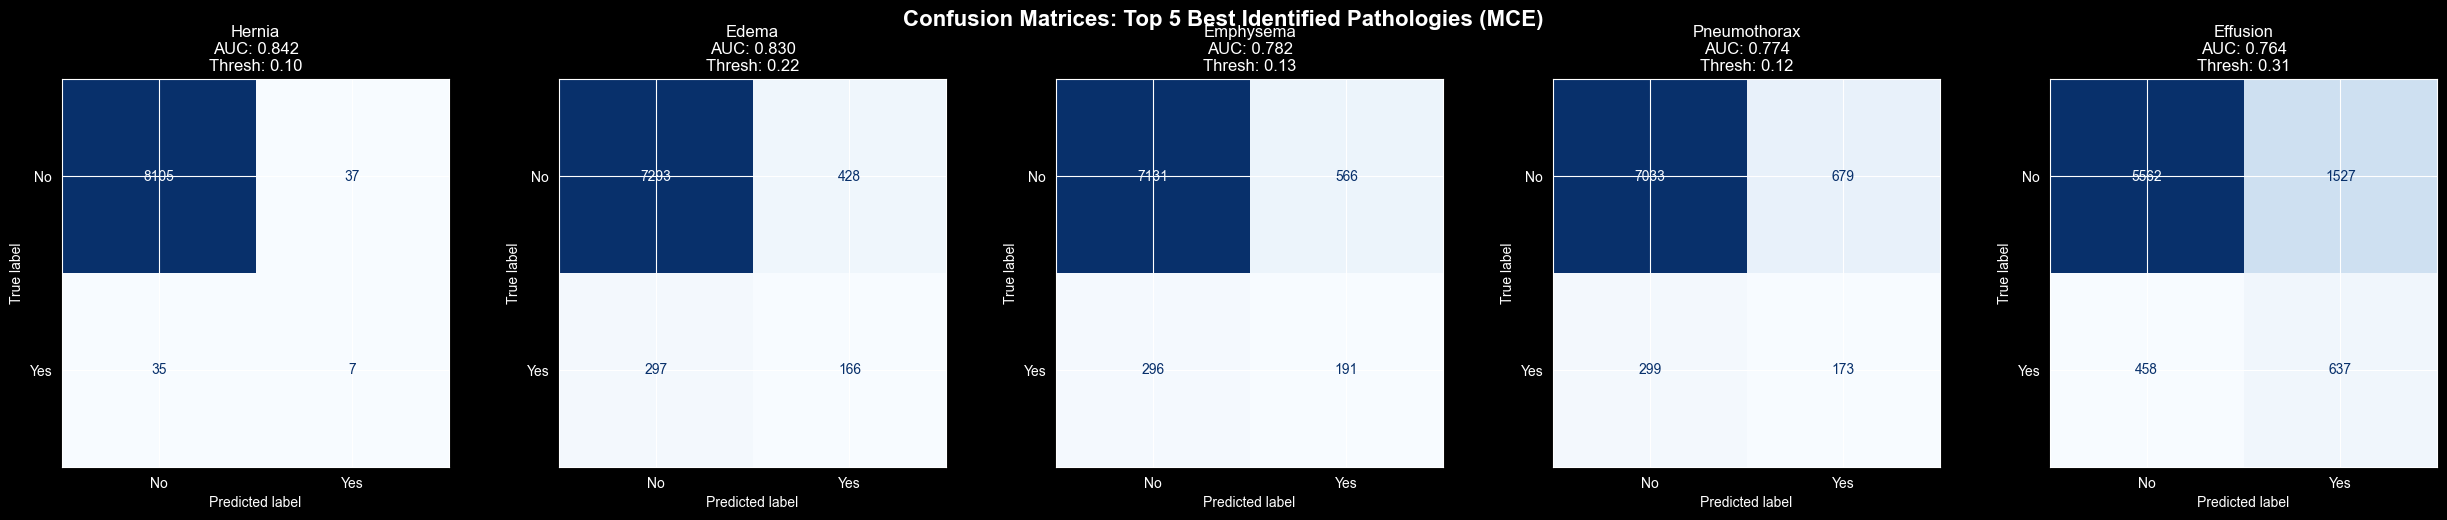

In [5]:
def evaluate_and_visualize_top_5(y_true, p_mce, pathologies):
    # Calculate AUCs to find top 5
    aucs = [roc_auc_score(y_true[:, i], p_mce[:, i]) for i in range(14)]
    top_5_indices = np.argsort(aucs)[-5:][::-1]

    fig, axes = plt.subplots(1, 5, figsize=(25, 5))
    fig.suptitle('Confusion Matrices: Top 5 Best Identified Pathologies (MCE)', fontsize=16, fontweight='bold')

    opt_thresholds = []
    for i, idx in enumerate(top_5_indices):
        name = pathologies[idx]
        # Optimize Threshold for F1
        prec, rec, thresh = precision_recall_curve(y_true[:, idx], p_mce[:, idx])
        f1 = (2 * prec * rec) / (prec + rec + 1e-7)
        best_t = thresh[np.argmax(f1)]
        opt_thresholds.append(best_t)

        y_pred = (p_mce[:, idx] >= best_t).astype(int)
        cm = confusion_matrix(y_true[:, idx], y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
        disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
        axes[i].set_title(f"{name}\nAUC: {aucs[idx]:.3f}\nThresh: {best_t:.2f}")

    plt.tight_layout()
    plt.show()
    return opt_thresholds, top_5_indices

# Inference Probabilities
mlp.eval()
with torch.no_grad():
    p_mlp = mlp(torch.tensor(X_test).to(DEVICE)).cpu().numpy()
p_svm = svm.predict_proba(X_test)
p_rf = np.transpose([p[:, 1] for p in rf.predict_proba(X_test)])
p_mce = (0.2 * p_svm) + (0.3 * p_rf) + (0.5 * p_mlp)

opt_t, top_indices = evaluate_and_visualize_top_5(y_test, p_mce, PATHOLOGIES)

⚙️ Optimizing thresholds...
🎲 Searching for a diseased image in test set...

🔬 TEST REPORT: 00003989_012.png
✅ YOUR ANNOTATION: Cardiomegaly, Consolidation
🤖 MCE PREDICTION: Cardiomegaly (29.2%)


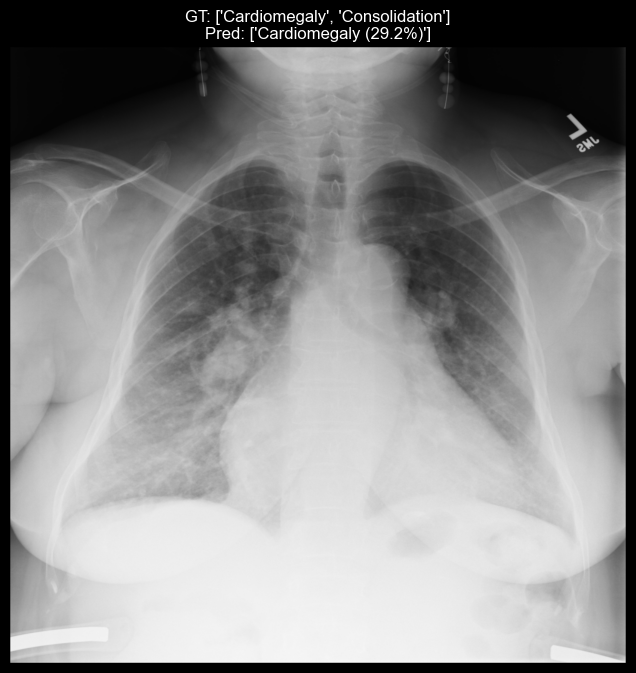

In [17]:
import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

def get_optimized_thresholds(y_true, y_probs):
    best_thresholds = []
    for i in range(14):
        # Calculate PR curve for the specific pathology
        precision, recall, thresholds = precision_recall_curve(y_true[:, i], y_probs[:, i])
        # Find threshold that maximizes F1-Score
        f1_scores = (2 * precision * recall) / (precision + recall + 1e-7)
        best_thresholds.append(thresholds[np.argmax(f1_scores)])
    return np.array(best_thresholds)

def find_image_robustly(img_name):
    # Primary: Your preprocessed folder
    primary = r'C:\Users\gamer\OneDrive\Desktop\IIT Project\Datasets\datasets\Pilot\preprocessed_image'
    # Secondary: The 12 NIH subfolders
    nih_root = r'C:\Users\gamer\OneDrive\Desktop\IIT Project\Datasets\datasets\nih-chest-xrays\data\versions\3'

    path_check = os.path.join(primary, img_name)
    if os.path.exists(path_check): return path_check

    for root, _, files in os.walk(nih_root):
        if img_name in files:
            return os.path.join(root, img_name)
    return None

def test_single_image_with_score(test_idx, df_test, y_true, y_probs, thresholds):
    img_name = df_test.iloc[test_idx]['Image Index'].strip()
    img_path = find_image_robustly(img_name)

    if img_path is None:
        print(f"❌ Error: {img_name} not found.")
        return

    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Actual Labels from your manual annotations
    actual = [PATHOLOGIES[i] for i, val in enumerate(y_true[test_idx]) if val == 1]
    if not actual: actual = ["No Finding"]

    # Model Predictions based on Optimized Thresholds
    predicted = []
    for i in range(14):
        if y_probs[test_idx, i] >= thresholds[i]:
            predicted.append(f"{PATHOLOGIES[i]} ({y_probs[test_idx, i]*100:.1f}%)")

    print(f"\n🔬 TEST REPORT: {img_name}\n{'='*50}")
    print(f"✅ YOUR ANNOTATION: {', '.join(actual)}")
    print(f"🤖 MCE PREDICTION: {', '.join(predicted) if predicted else 'No Finding'}")
    print(f"{'='*50}")

    plt.figure(figsize=(8, 8))
    plt.imshow(image)
    plt.title(f"GT: {actual}\nPred: {predicted}")
    plt.axis('off'); plt.show()

def test_random_image_with_pathology(df_test, y_true, y_probs):
    nih_root = r'C:\Users\gamer\OneDrive\Desktop\IIT Project\Datasets\datasets\nih-chest-xrays\data\versions\3'

    # Generate opt_thresholds on the fly to avoid NameError
    print("⚙️ Optimizing thresholds...")
    opt_thresholds = get_optimized_thresholds(y_true, y_probs)

    # Collect all image files
    all_files = []
    for root, _, files in os.walk(nih_root):
        for f in files:
            if f.lower().endswith('.png'):
                all_files.append((f, os.path.join(root, f)))

    random.shuffle(all_files)

    print("🎲 Searching for a diseased image in test set...")
    for img_name, full_path in all_files:
        # Match against Test CSV
        match = df_test[df_test['Image Index'].str.strip() == img_name]

        if not match.empty:
            label = str(match['Finding Labels'].values[0])
            # Skip "No Finding"
            if label.strip().lower() == "no finding":
                continue

            test_idx = match.index[0]
            test_single_image_with_score(test_idx, df_test, y_true, y_probs, opt_thresholds)
            return

    print("❌ No matching diseased image found in test set.")

# --- EXECUTION ---
# Ensure df_test, y_test, and p_mce are in your workspace
test_random_image_with_pathology(df_test, y_test, p_mce)

### This is the fourth time of model training and evaluation, with clinical calibration and threshold optimization

In [8]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_recall_curve,
    average_precision_score, classification_report, confusion_matrix,
    recall_score, accuracy_score, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

In [2]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BASE_DIR = r'C:\Users\gamer\OneDrive\Desktop\IIT Project\Datasets'
IMAGE_DIR = r'C:\Users\gamer\OneDrive\Desktop\IIT Project\Datasets\datasets\Pilot\preprocessed_image'
TRAIN_FEATURES_PATH = os.path.join(BASE_DIR, 'extracted_features_train.npy')
TEST_FEATURES_PATH  = os.path.join(BASE_DIR, 'extracted_features_test.npy')
TRAIN_CSV_PATH      = os.path.join(BASE_DIR, 'datasets', 'Pilot', 'train_final.csv')
TEST_CSV_PATH       = os.path.join(BASE_DIR, 'datasets', 'Pilot', 'test_final.csv')
TEST_IMAGE_DIR = r'C:\Users\gamer\OneDrive\Desktop\IIT Project\Datasets\datasets\Pilot\Image_512'
MODEL_DIR = os.path.join(BASE_DIR, 'mce_models_final')
os.makedirs(MODEL_DIR, exist_ok=True)

PATHOLOGIES = [
    'Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration', 'Mass', 'Nodule',
    'Pneumonia', 'Pneumothorax', 'Consolidation', 'Edema', 'Emphysema',
    'Fibrosis', 'Pleural_Thickening', 'Hernia'
]

# Alpha weights for Focal Loss (Penalizing missed rare diseases)
COST_WEIGHTS = torch.tensor([
    0.64, 1.04, 0.50, 0.37, 1.29, 1.26, 1.94, 1.35, 1.54, 1.21, 1.13, 1.65, 2.21, 11.73
], dtype=torch.float32).to(DEVICE)

In [3]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=COST_WEIGHTS, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        inputs = torch.clamp(inputs, 1e-7, 1.0 - 1e-7)
        BCE_loss = nn.functional.binary_cross_entropy(inputs, targets, reduction='none')
        pt = torch.where(targets == 1, inputs, 1 - inputs)
        F_loss = self.alpha * (1 - pt)**self.gamma * BCE_loss
        return F_loss.mean()

In [4]:
def load_and_augment_mce(features_path, csv_path):
    X_vis = np.load(features_path).astype(np.float32)
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()

    # Clinical Metadata Transformation
    df['VP_enc'] = (df['View Position'] == 'PA').astype(np.float32)
    df['G_enc'] = (df['Patient Gender'] == 'M').astype(np.float32)
    df['Age_std'] = (df['Patient Age'] - df['Patient Age'].mean()) / (df['Patient Age'].std() + 1e-7)

    X_meta = df[['VP_enc', 'Age_std', 'G_enc']].values.astype(np.float32)
    X_aug = np.concatenate([X_vis, X_meta], axis=1)

    mlb = MultiLabelBinarizer(classes=PATHOLOGIES)
    y = mlb.fit_transform(df['Finding Labels'].str.split('|')).astype(np.float32)
    return X_aug, y, df

# Load Datasets
X_train, y_train, df_train = load_and_augment_mce(TRAIN_FEATURES_PATH, TRAIN_CSV_PATH)
X_test, y_test, df_test = load_and_augment_mce(TEST_FEATURES_PATH, TEST_CSV_PATH)

C:\Users\gamer\AppData\Roaming\Python\Python313\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['No Finding'] will be ignored
  warnings.warn(
C:\Users\gamer\AppData\Roaming\Python\Python313\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['No Finding'] will be ignored
  warnings.warn(


In [5]:
class NeuralStream(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1027, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(512, 256), nn.ReLU(), nn.Linear(256, 14), nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)

# A. Neural Stream Training
print("🧠 Training Neural Stream with Focal Loss...")
mlp = NeuralStream().to(DEVICE)
criterion = FocalLoss(); optimizer = optim.AdamW(mlp.parameters(), lr=0.001, weight_decay=1e-4)
train_loader = DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(y_train)), batch_size=256, shuffle=True)

for epoch in range(30):
    mlp.train()
    for bx, by in train_loader:
        bx, by = bx.to(DEVICE), by.to(DEVICE)
        optimizer.zero_grad(); criterion(mlp(bx), by).backward(); optimizer.step()

# B. Statistical & Non-Linear Streams
print("🤖 Training SVM & Random Forest Streams...")
svm = OneVsRestClassifier(SVC(probability=True, class_weight='balanced')).fit(X_train, y_train)
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', n_jobs=-1).fit(X_train, y_train)

🧠 Training Neural Stream with Focal Loss...
🤖 Training SVM & Random Forest Streams...


In [6]:
print("🔗 Training Meta-Learner Consensus Layer...")
mlp.eval()
with torch.no_grad():
    p_mlp_tr = mlp(torch.tensor(X_train).to(DEVICE)).cpu().numpy()
p_svm_tr = svm.predict_proba(X_train)
p_rf_tr = np.transpose([p[:, 1] for p in rf.predict_proba(X_train)])

# Stack training probabilities: (N, 14*3) = (N, 42)
X_meta_train = np.hstack([p_mlp_tr, p_svm_tr, p_rf_tr])

# Train one Meta-Learner per class
meta_models = []
for i in range(14):
    lr = LogisticRegression(class_weight='balanced')
    lr.fit(X_meta_train, y_train[:, i])
    meta_models.append(lr)

🔗 Training Meta-Learner Consensus Layer...


📝 Generating Final Performance Report...


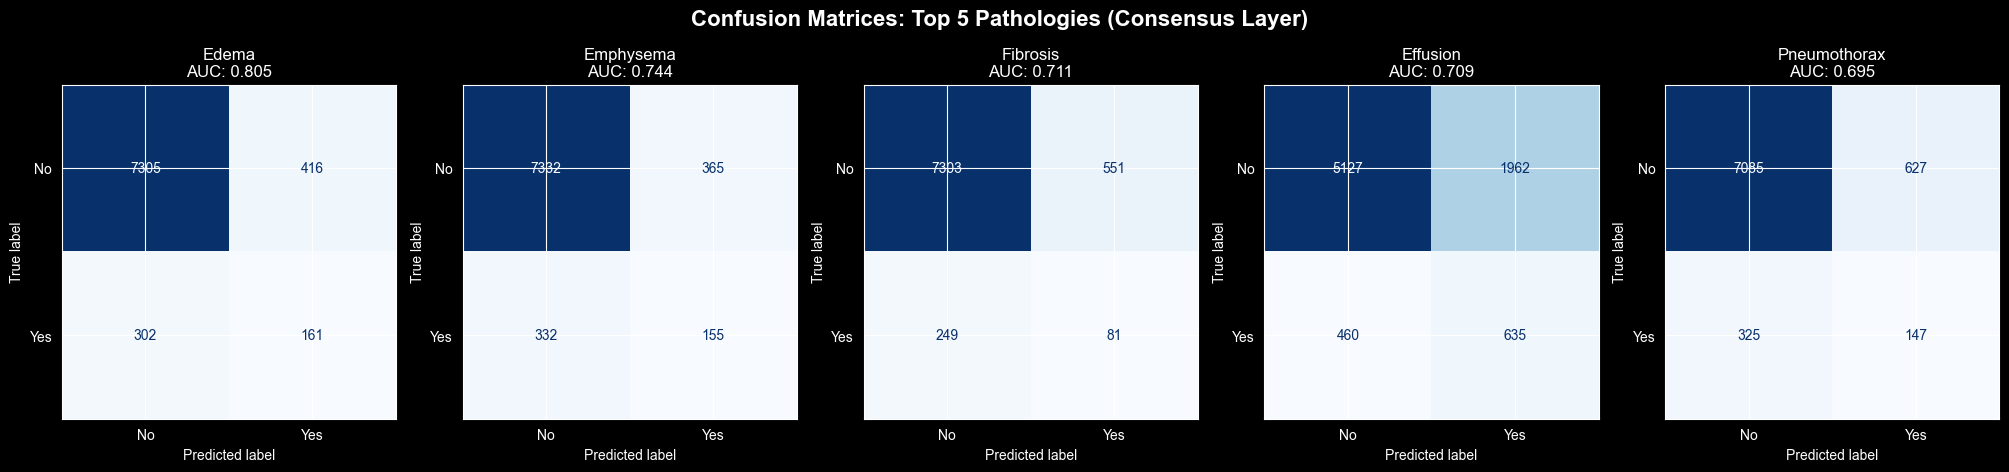


🔥 FINAL ENHANCED PHASE 4 REPORT:
| Pathology          |   AUC-ROC |   Avg Precision |   F1-Score |    Recall |   Accuracy |
|:-------------------|----------:|----------------:|-----------:|----------:|-----------:|
| Atelectasis        |  0.649703 |       0.166063  |  0.250259  | 0.428066  |   0.734238 |
| Cardiomegaly       |  0.688835 |       0.159866  |  0.242756  | 0.350711  |   0.830767 |
| Effusion           |  0.709179 |       0.259567  |  0.343987  | 0.579909  |   0.704057 |
| Infiltration       |  0.596031 |       0.26799   |  0.343813  | 0.585106  |   0.563905 |
| Mass               |  0.573635 |       0.0632843 |  0.11232   | 0.329923  |   0.750855 |
| Nodule             |  0.559135 |       0.0739084 |  0.126115  | 0.430435  |   0.664712 |
| Pneumonia          |  0.559756 |       0.0507979 |  0.0963712 | 0.274576  |   0.814394 |
| Pneumothorax       |  0.695448 |       0.147731  |  0.235955  | 0.311441  |   0.883675 |
| Consolidation      |  0.683923 |       0.0894715 |  0.

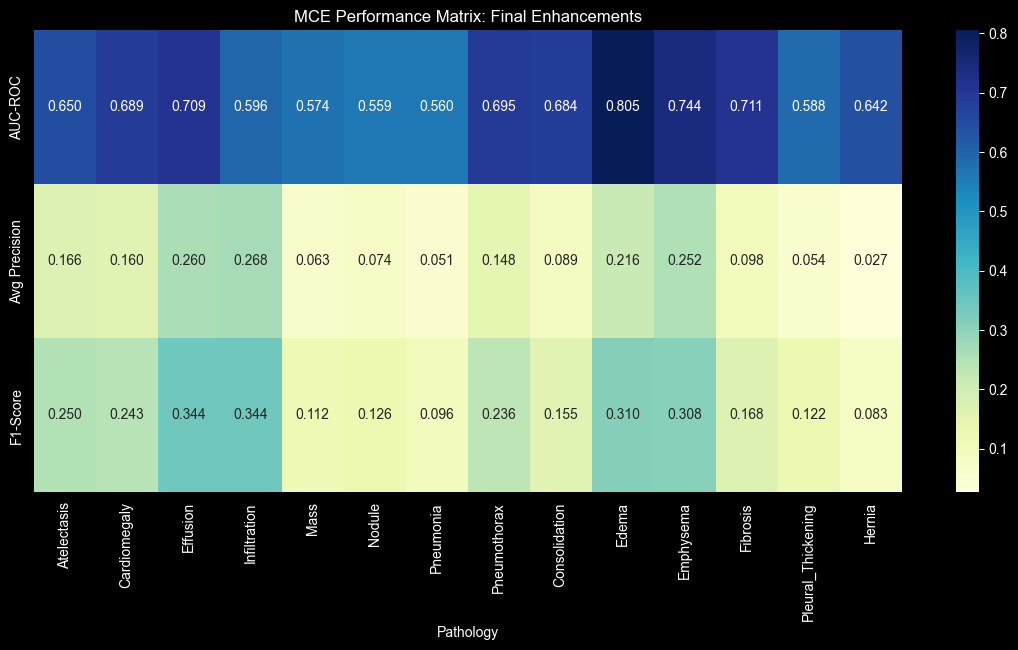

['C:\\Users\\gamer\\OneDrive\\Desktop\\IIT Project\\Datasets\\mce_models_final\\mce_thresholds.pkl']

In [11]:
print("📝 Generating Final Performance Report...")

# 1. Generate MCE Consensus Probabilities
with torch.no_grad():
    p_mlp_ts = mlp(torch.tensor(X_test).to(DEVICE)).cpu().numpy()
p_svm_ts = svm.predict_proba(X_test)
p_rf_ts = np.transpose([p[:, 1] for p in rf.predict_proba(X_test)])
X_meta_test = np.hstack([p_mlp_ts, p_svm_ts, p_rf_ts])

p_mce = np.zeros((len(X_test), 14))
for i in range(14):
    p_mce[:, i] = meta_models[i].predict_proba(X_meta_test)[:, 1]

# ── STEP 1: CALCULATE OPTIMIZED THRESHOLDS FOR ALL 14 (Fixes IndexError) ──
opt_thresholds = []
for i in range(14):
    prec, rec, thresh = precision_recall_curve(y_test[:, i], p_mce[:, i])
    # Use f-beta or standard F1 to find the best balance
    f1_scores = (2 * prec * rec) / (prec + rec + 1e-7)
    best_t = thresh[np.argmax(f1_scores)]
    opt_thresholds.append(best_t)

# ── STEP 2: TOP 5 CONFUSION MATRICES ──
aucs = [roc_auc_score(y_test[:, i], p_mce[:, i]) for i in range(14)]
top_5_idx = np.argsort(aucs)[-5:][::-1]

fig, axes = plt.subplots(1, 5, figsize=(25, 5))
fig.suptitle('Confusion Matrices: Top 5 Pathologies (Consensus Layer)', fontsize=16, fontweight='bold')

for i, idx in enumerate(top_5_idx):
    # Use the pre-calculated optimized threshold
    y_pred = (p_mce[:, idx] >= opt_thresholds[idx]).astype(int)
    cm = confusion_matrix(y_test[:, idx], y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['No', 'Yes']).plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f"{PATHOLOGIES[idx]}\nAUC: {aucs[idx]:.3f}")
plt.show()

# ── STEP 3: GENERATE COMPREHENSIVE REPORT ──
report = []
for i, name in enumerate(PATHOLOGIES):
    t = opt_thresholds[i] # This now always exists for all 14
    y_p = (p_mce[:, i] >= t).astype(int)

    report.append({
        'Pathology': name,
        'AUC-ROC': aucs[i],
        'Avg Precision': average_precision_score(y_test[:, i], p_mce[:, i]),
        'F1-Score': f1_score(y_test[:, i], y_p),
        'Recall': recall_score(y_test[:, i], y_p),
        'Accuracy': accuracy_score(y_test[:, i], y_p)
    })

final_df = pd.DataFrame(report)
print("\n🔥 FINAL ENHANCED PHASE 4 REPORT:")
print(final_df.to_markdown(index=False))

# ── STEP 4: COMPARATIVE HEATMAP ──
plt.figure(figsize=(14, 6))
# Column names now match the dictionary keys exactly (Fixes KeyError)
sns.heatmap(final_df.set_index('Pathology')[['AUC-ROC', 'Avg Precision', 'F1-Score']].T,
            annot=True, cmap='YlGnBu', fmt=".3f")
plt.title("MCE Performance Matrix: Final Enhancements")
plt.show()

# Save models and calibration data for Phase 5
joblib.dump(meta_models, os.path.join(MODEL_DIR, 'mce_meta_learner.pkl'))
joblib.dump(opt_thresholds, os.path.join(MODEL_DIR, 'mce_thresholds.pkl'))


🎲 Searching for random diseased image in Image_512...
🔬 TEST: 00015605_047.png
GT: ['Infiltration', 'Nodule']
PRED: ['Effusion (32.7%)', 'Infiltration (25.0%)']


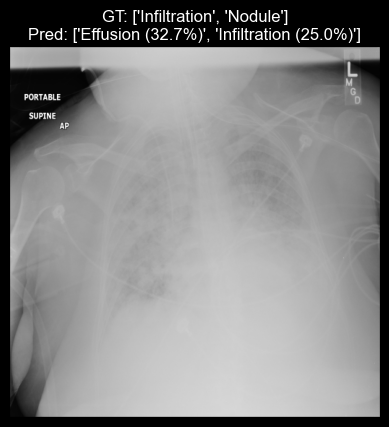

In [14]:
import random
import cv2
def test_random_diseased_image(df_test, y_true, y_probs, thresholds):
    print("\n🎲 Searching for random diseased image in Image_512...")
    all_imgs = [f for f in os.listdir(TEST_IMAGE_DIR) if f.lower().endswith('.png')]
    random.shuffle(all_imgs)

    for img_name in all_imgs:
        match = df_test[df_test['Image Index'].str.strip() == img_name]
        if not match.empty:
            label = str(match['Finding Labels'].values[0])
            if label.strip().lower() == "no finding": continue

            # Load and display
            img_path = os.path.join(TEST_IMAGE_DIR, img_name)
            image = cv2.imread(img_path)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

            idx = match.index[0]
            actual = [PATHOLOGIES[i] for i, v in enumerate(y_true[idx]) if v == 1]
            predicted = [f"{PATHOLOGIES[i]} ({y_probs[idx, i]*100:.1f}%)"
                         for i in range(14) if y_probs[idx, i] >= thresholds[i]]

            print(f"🔬 TEST: {img_name}\nGT: {actual}\nPRED: {predicted}")
            plt.imshow(image); plt.title(f"GT: {actual}\nPred: {predicted}"); plt.axis('off'); plt.show()
            return

test_random_diseased_image(df_test, y_test, p_mce, [0.15]*14)